# Clustering

This notebook goes through a clustering process using a dataset focused on audio tracks sourced from Spotify.

## Imports

In [47]:
import pandas as pd
import altair as alt
alt.data_transformers.enable("vegafusion")
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Data Sourcing

In [2]:
tracks = pd.read_csv("spotify_songs.csv")
tracks.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
tracks.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [4]:
tracks.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [5]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [6]:
tracks.dtypes

track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [7]:
tracks = tracks.dropna()

## Pre-processing

'k'-Means requires:

- numeric columns
- no labels
- scaled to match 

In [14]:
# Select the columns we'll choose to cluster

clustering_data = tracks[["valence", "tempo"]]

In [24]:
# Scale the data

scaler = StandardScaler()

clustering_data = scaler.fit_transform(clustering_data)

## Hyper-parameter searching

In [49]:
cluster_scores = []

for k in range(1, 50):
    score = KMeans(n_clusters=k).fit(clustering_data).inertia_
    cluster_scores.append((k, score))

cluster_scores = pd.DataFrame(data=cluster_scores, columns=["k", "inertia"])


<Axes: xlabel='k', ylabel='inertia'>

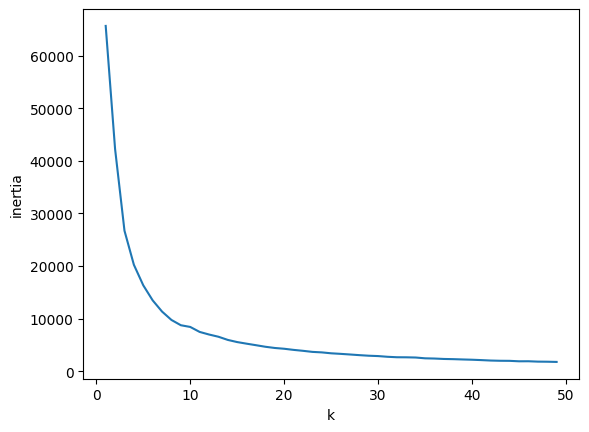

In [50]:
sns.lineplot(cluster_scores, x="k", y="inertia")

## Data Modelling

In [51]:
# Make a model

model = KMeans(n_clusters=10)



In [52]:
# Train the data (fit)
model.fit(clustering_data)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


## Evaluation

In [53]:
cluster_pred = model.predict(clustering_data)

In [54]:
pd.Series(cluster_pred).value_counts()

8    4463
0    4341
9    4258
5    3851
4    3492
7    2901
1    2867
2    2347
6    2296
3    2012
Name: count, dtype: int64

In [55]:
human_understandable = tracks[["track_name", "track_artist", "playlist_genre", "valence" , "tempo"]]

In [56]:
human_understandable["cluster"] = cluster_pred

/var/folders/c2/_878xg9s4nlfrtmsmzqhqq5m0000gp/T/ipykernel_64824/1526849156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_understandable["cluster"] = cluster_pred


In [57]:
human_understandable

,track_name,track_artist,playlist_genre,valence,tempo,cluster
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,pop,0.5180,122.036,9
1,Memories - Dillon Francis Remix,Maroon 5,pop,0.6930,99.972,4
2,All the Time - Don Diablo Remix,Zara Larsson,pop,0.6130,124.008,9
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,pop,0.2770,121.956,0
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,pop,0.7250,123.976,9
...,...,...,...,...,...,...
32828,City Of Lights - Official Radio Edit,Lush & Simon,edm,0.2100,128.170,0
32829,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,edm,0.4000,128.041,8
32830,Sweet Surrender - Radio Edit,Starkillers,edm,0.4360,127.989,8
32831,Only For You - Maor Levi Remix,Mat Zo,edm,0.3080,128.008,8


In [61]:
alt.Chart(human_understandable).mark_point().encode(
    x="valence",
    y="tempo",
    color="cluster:N"
)

alt.Chart(...)

In [60]:
human_understandable[human_understandable["cluster"] == 1].head(20)

,track_name,track_artist,playlist_genre,valence,tempo,cluster
10,Cross Me (feat. Chance the Rapper & PnB Rock) ...,Ed Sheeran,pop,0.752,121.984,1
29,When You Leave - Breathe Carolina Remix,Nikki Vianna,pop,0.819,119.885,1
35,Love Me Less (feat. Quinn XCII) - Party Pupils...,MAX,pop,0.894,128.024,1
36,Happier - Matt Medved Remix,Marshmello,pop,0.793,122.032,1
59,All Star - Breathe Carolina Remix,Smash Mouth,pop,0.751,115.018,1
66,Spicy - Majestic Remix,Herve Pagez,pop,0.959,121.978,1
114,Ritual,Tiësto,pop,0.767,114.996,1
127,Sorry,Joel Corry,pop,0.847,125.002,1
165,Poker Face,Lady Gaga,pop,0.776,119.001,1
184,So Close,NOTD,pop,0.761,125.030,1
